In [20]:
import pandas as pd
import numpy as np

In [21]:
df=pd.read_csv('data_core.csv')

In [22]:
df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [23]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report



In [24]:
preprocessor = ColumnTransformer(

transformers=[

('cat', OneHotEncoder(), ['Soil Type', 'Crop Type'])

],

remainder='passthrough'

)

In [25]:
X = df.drop('Fertilizer Name', axis=1)

y = df['Fertilizer Name']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [26]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [27]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [28]:
y_pred = model.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.14125
              precision    recall  f1-score   support

    10-26-26       0.15      0.15      0.15       241
    14-35-14       0.12      0.13      0.13       241
    17-17-17       0.09      0.10      0.09       215
       20-20       0.17      0.14      0.16       236
       28-28       0.13      0.13      0.13       219
         DAP       0.16      0.15      0.16       239
        Urea       0.16      0.19      0.17       209

    accuracy                           0.14      1600
   macro avg       0.14      0.14      0.14      1600
weighted avg       0.14      0.14      0.14      1600



In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [30]:
df = pd.read_csv('data_core.csv')
print(df.head())
print(df['Fertilizer Name'].value_counts())

   Temparature  Humidity  Moisture Soil Type  Crop Type  Nitrogen  Potassium  \
0         26.0      52.0      38.0     Sandy      Maize        37          0   
1         29.0      52.0      45.0     Loamy  Sugarcane        12          0   
2         34.0      65.0      62.0     Black     Cotton         7          9   
3         32.0      62.0      34.0       Red    Tobacco        22          0   
4         28.0      54.0      46.0    Clayey      Paddy        35          0   

   Phosphorous Fertilizer Name  
0            0            Urea  
1           36             DAP  
2           30        14-35-14  
3           20           28-28  
4            0            Urea  
Fertilizer Name
14-35-14    1188
Urea        1170
DAP         1167
10-26-26    1128
17-17-17    1124
28-28       1120
20-20       1103
Name: count, dtype: int64


In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['Soil Type', 'Crop Type']),  # Encode categorical features
        ('num', StandardScaler(), ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous'])
    ]
)

# Split data into features (X) and target (y)
X = df.drop('Fertilizer Name', axis=1)
y = df['Fertilizer Name']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [32]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [33]:
y_pred = model.predict(X_test_processed)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.153125
              precision    recall  f1-score   support

    10-26-26       0.16      0.15      0.15       241
    14-35-14       0.14      0.15      0.14       241
    17-17-17       0.10      0.13      0.11       215
       20-20       0.17      0.14      0.15       236
       28-28       0.19      0.18      0.18       219
         DAP       0.19      0.18      0.18       239
        Urea       0.14      0.17      0.15       209

    accuracy                           0.15      1600
   macro avg       0.16      0.15      0.15      1600
weighted avg       0.16      0.15      0.15      1600



In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Load data
df = pd.read_csv('data_core.csv')

# Check for missing values
print(df.isnull().sum())

# Define preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['Soil Type', 'Crop Type']),
        ('num', StandardScaler(), ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous'])
    ]
)

# Split data
X = df.drop('Fertilizer Name', axis=1)
y = df['Fertilizer Name']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # Stratify for class balance

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64


In [35]:
# Use class weights or SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

In [36]:
# Install the imblearn package
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Accuracy: 0.83
              precision    recall  f1-score   support

    10-26-26       0.84      0.79      0.81       226
    14-35-14       0.83      0.83      0.83       238
    17-17-17       0.83      0.88      0.86       225
       20-20       0.84      0.77      0.80       220
       28-28       0.82      0.88      0.85       224
         DAP       0.83      0.81      0.82       233
        Urea       0.81      0.85      0.83       234

    accuracy                           0.83      1600
   macro avg       0.83      0.83      0.83      1600
weighted avg       0.83      0.83      0.83      1600



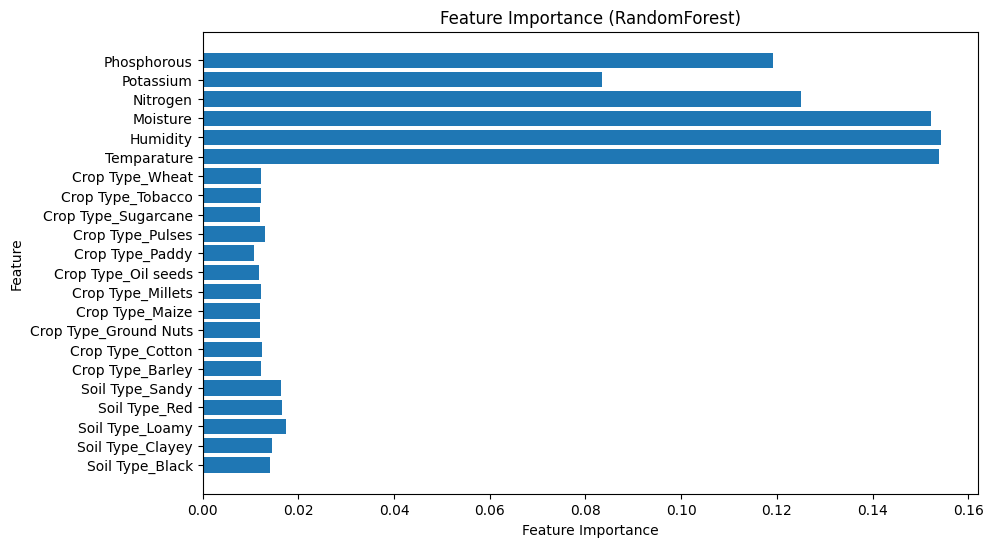

In [38]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_processed)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature importance (RandomForest)
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
feature_importances = model.feature_importances_

# Get feature names from the preprocessor
categorical_features = preprocessor.transformers_[0][2]
numerical_features = preprocessor.transformers_[1][2]
feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)) + numerical_features

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (RandomForest)")
plt.show()

In [39]:
new_data = pd.DataFrame({
    'Temparature': [28.5],      
    'Humidity': [60],
    'Moisture': [45],
    'Soil Type': ['Loamy'],
    'Crop Type': ['Wheat'],
    'Nitrogen': [25],
    'Potassium': [10],
    'Phosphorous': [15]
})

In [40]:
new_data_processed = preprocessor.transform(new_data)

In [41]:
predicted_fertilizer = model.predict(new_data_processed)
print("Recommended Fertilizer:", predicted_fertilizer[0])

Recommended Fertilizer: 20-20


In [42]:
import pickle

In [43]:
pickle.dump(model, open('fertilizer_model.pkl', 'wb'))

In [44]:
pickle.dump(preprocessor, open('preprocessor.pkl', 'wb'))